# CAER-S – 4-Class Emotion Classification (v7)

Real images only. Stable training pipeline.

**Emotion clusters:**
| ID | Label | Source emotions |
|----|-------|-----------------|
| 0 | Optimistic  | Happy |
| 1 | Pessimistic | Sadness + Fear             |
| 2 | Hostile     | Anger + Disgust            |
| 3 | Neutral     | Neutral |

**Changes in v7 vs v6:**
- CrossEntropyLoss restored (focal loss removed — too many interacting failure modes
  with MixUp and an unstable backbone at unfreeze time)
- Backbone LR reduced 10× (`5e-6 → 5e-7`) to prevent catastrophic forgetting
- Phase 2 split into two sub-phases:
  - **2a**: head-only training at full `lr_head_ft` for 2 epochs after MixUp enabled
  - **2b**: full unfreeze with very conservative backbone LR + cosine schedule
- MixUp disabled for the first unfrozen epoch to let the head stabilise
- Focal loss kept as an optional drop-in (commented out) for after convergence


## 1. Config

In [1]:
from dataclasses import dataclass
import torch


@dataclass
class Config:
    # --- data ---
    data_csv:    str = "/home/simon/Documents/Zwischen Wörtern und Pixeln/annotations-caer_cleaned_4cluster.csv"
    image_col:   str = "image_path"
    label_col:   str = "emotion_recode2"   # 0=Optimistic 1=Pessimistic 2=Hostile 3=Neutral
    num_classes: int = 4
    img_size:    int = 224
    val_ratio:  float = 0.2
    random_seed: int = 42

    # --- model ---
    model_name:     str   = "deit_base_patch16_224"
    pretrained:     bool  = True
    drop_rate:     float  = 0.3    # dropout before the classification head
    drop_path_rate: float = 0.1    # stochastic depth, enabled at Phase 2b only
    batch_size: int = 64

    # --- training phases ---
    # Phase 1  : backbone frozen, head only, no MixUp
    epochs_frozen:   int   = 3
    lr_head:        float  = 1e-4

    # Phase 2a : backbone still frozen, MixUp enabled, head consolidates
    epochs_head:     int   = 2
    lr_head_warmup: float  = 5e-5   # slightly lower than Phase 1 for stability

    # Phase 2b : full fine-tune, conservative backbone LR
    epochs_finetune: int   = 30     # early stopping will cut this short
    lr_backbone:    float  = 5e-6   
    lr_head_ft:     float  = 2e-5

    weight_decay:   float  = 1e-4
    grad_clip:      float  = 1.0

    # --- MixUp ---
    # Disabled in Phase 1 and first epoch of Phase 2b.
    # Enabled in Phase 2a onward.
    mixup_alpha: float = 0.2

    # --- early stopping ---
    patience: int = 7

    # --- system ---
    num_workers: int = 8
    device:      str = "cuda"


cfg = Config()
cfg.device = torch.device(cfg.device)

EMOTION_NAMES = ["Optimistic", "Pessimistic", "Hostile", "Neutral"]

print("Config ready. Device:", cfg.device)
print("Classes:", EMOTION_NAMES)
print(f"Total epochs (max): {cfg.epochs_frozen} + {cfg.epochs_head} + {cfg.epochs_finetune} = "
      f"{cfg.epochs_frozen + cfg.epochs_head + cfg.epochs_finetune}")


Config ready. Device: cuda
Classes: ['Optimistic', 'Pessimistic', 'Hostile', 'Neutral']
Total epochs (max): 3 + 2 + 30 = 35


## 2. Data Utilities

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import WeightedRandomSampler


def stratified_split(cfg):
    """Stratified 80/20 split. Casts float CSV labels to int."""
    df = pd.read_csv(cfg.data_csv, 
                     low_memory = False) #read whole file before inferring types
    df[cfg.label_col] = df[cfg.label_col].astype(int)

    assert set(df[cfg.label_col].unique()) <= {0, 1, 2, 3}, \
        f"Unexpected label values: {sorted(df[cfg.label_col].unique())}"

    train_df, val_df = train_test_split(
        df,
        test_size    = cfg.val_ratio,
        stratify     = df[cfg.label_col],
        random_state = cfg.random_seed,
    )
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True)


def compute_class_weights(train_df, cfg):
    """Sqrt inverse-frequency weights, normalised to mean=1."""
    counts  = train_df[cfg.label_col].value_counts().sort_index()
    weights = 1.0 / np.sqrt(counts)
    weights = weights / weights.sum() * cfg.num_classes
    return torch.tensor(weights.values, dtype=torch.float)


def build_sampler(train_df, cfg):
    """WeightedRandomSampler for roughly balanced training batches."""
    counts         = train_df[cfg.label_col].value_counts().to_dict()
    sample_weights = train_df[cfg.label_col].map(lambda c: 1.0 / counts[c])
    return WeightedRandomSampler(
        weights     = torch.tensor(sample_weights.values, dtype=torch.double),
        num_samples = len(sample_weights),
        replacement = True,
    )


# ---- run ----
train_df, val_df = stratified_split(cfg)
class_weights    = compute_class_weights(train_df, cfg).to(cfg.device)

print(f"Train: {len(train_df)}  |  Val: {len(val_df)}")
print("Class weights:",
      {EMOTION_NAMES[i]: f"{class_weights[i].item():.3f}" for i in range(cfg.num_classes)})
print("\nTrain distribution:")
print(train_df[cfg.label_col].value_counts().sort_index()
      .rename(index=dict(enumerate(EMOTION_NAMES))).to_string())
print("\nVal distribution:")
print(val_df[cfg.label_col].value_counts().sort_index()
      .rename(index=dict(enumerate(EMOTION_NAMES))).to_string())


Train: 48000  |  Val: 12000
Class weights: {'Optimistic': '1.172', 'Pessimistic': '0.828', 'Hostile': '0.828', 'Neutral': '1.172'}

Train distribution:
emotion_recode2
Optimistic      8000
Pessimistic    16000
Hostile        16000
Neutral         8000

Val distribution:
emotion_recode2
Optimistic     2000
Pessimistic    4000
Hostile        4000
Neutral        2000


## 3. Transforms

Identical ImageNet normalisation for train and val.
Training: RandomResizedCrop, HorizontalFlip, BrightnessContrast, HueSaturationValue, Rotate, GaussNoise, CoarseDropout.

In [3]:
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)


def get_transforms(cfg, train=True):
    """Return albumentations pipeline.

    Training augmentations are slightly stronger than v4 to combat the
    train/val overfitting gap:
      - CoarseDropout probability raised from 0.3 to 0.5
      - GaussNoise added (p=0.3) — simulates image quality variation

    Validation: only resize + normalise. No stochastic ops.
    """
    norm = A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)

    if train:
        return A.Compose([
            A.RandomResizedCrop(size=(cfg.img_size, cfg.img_size), scale=(0.75, 1.0)),
            A.HorizontalFlip(p=0.5),
            A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5),
            A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.3),
            A.Rotate(limit=15, p=0.5),
            A.GaussNoise(p=0.3),
            A.CoarseDropout(max_holes=1, max_height=48, max_width=48,
                            min_holes=1, min_height=16, min_width=16, p=0.5),
            norm,
            ToTensorV2(),
        ])
    else:
        return A.Compose([
            A.Resize(cfg.img_size, cfg.img_size),
            norm,
            ToTensorV2(),
        ])


class EmotionDataset(Dataset):
    """Loads images with OpenCV, applies albumentations transforms.

    Returns (image_tensor, label) where label is an int in [0, num_classes).
    """

    def __init__(self, df, cfg, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform
        self.image_col = cfg.image_col
        self.label_col = cfg.label_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = cv2.imread(row[self.image_col])
        if image is None:
            raise FileNotFoundError(f"Image not found: {row[self.image_col]}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if self.transform:
            image = self.transform(image=image)["image"]
        return image, int(row[self.label_col])


# ---- build datasets & loaders ----
train_ds = EmotionDataset(train_df, cfg, transform=get_transforms(cfg, train=True))
val_ds   = EmotionDataset(val_df,   cfg, transform=get_transforms(cfg, train=False))

train_sampler = build_sampler(train_df, cfg)

train_loader = DataLoader(
    train_ds,
    batch_size  = cfg.batch_size,
    sampler     = train_sampler,
    num_workers = cfg.num_workers,
    pin_memory  = True,
)
val_loader = DataLoader(
    val_ds,
    batch_size  = cfg.batch_size,
    shuffle     = False,
    num_workers = cfg.num_workers,
    pin_memory  = True,
)

# Sanity check
imgs, labels = next(iter(train_loader))
print("Batch image shape :", imgs.shape)
print("Batch label shape :", labels.shape)
print("Label dtype        :", labels.dtype)
print("Pixel min/max      :", round(imgs.min().item(), 3), round(imgs.max().item(), 3))
assert imgs.shape[1:] == (3, cfg.img_size, cfg.img_size)
assert labels.dtype == torch.long
print("Sanity check passed.")


/tmp/ipykernel_50801/2300854325.py:30: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, min_height, min_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=1, max_height=48, max_width=48,


Batch image shape : torch.Size([64, 3, 224, 224])
Batch label shape : torch.Size([64])
Label dtype        : torch.int64
Pixel min/max      : -2.118 2.64
Sanity check passed.


## 4. Model

Same DeiT-Base as v6 with the same `init_head()` and `check_pred_distribution()` guards. `drop_path_rate` starts at 0.0 and is enabled at Phase 2b start via `enable_drop_path()`.

In [4]:
import timm
import collections
import torch.nn as nn


def build_model(cfg):
    """Create DeiT-Base. drop_path disabled until Phase 2b."""
    model = timm.create_model(
        cfg.model_name,
        pretrained     = cfg.pretrained,
        num_classes    = cfg.num_classes,
        drop_rate      = cfg.drop_rate,
        drop_path_rate = 0.0,
    )
    return model


def init_head(model):
    """Reinitialise head with neutral weights to prevent pre-training collapse."""
    torch.nn.init.trunc_normal_(model.head.weight, std=0.02)
    torch.nn.init.zeros_(model.head.bias)
    print("Head reinitialised.")


def check_pred_distribution(model, loader, cfg, label=""):
    """Verify model predicts all classes before training starts."""
    model.eval()
    all_preds = []
    with torch.no_grad():
        for images, _ in loader:
            preds = model(images.to(cfg.device)).argmax(dim=1)
            all_preds.extend(preds.cpu().tolist())
    counts = dict(sorted(collections.Counter(all_preds).items()))
    total  = len(all_preds)
    pct    = {EMOTION_NAMES[k]: f"{v/total*100:.1f}%" for k, v in counts.items()}
    print(f"Pred distribution {label}: {pct}")
    dominant = max(counts.values()) / total
    if dominant > 0.8:
        print("  ⚠ WARNING: one class dominates — check head initialisation before training.")
    return counts


def enable_drop_path(model, rate):
    """Enable stochastic depth at Phase 2b start."""
    from timm.layers import DropPath
    count = 0
    for module in model.modules():
        if isinstance(module, DropPath):
            module.drop_prob = rate
            count += 1
    print(f"drop_path_rate set to {rate} on {count} DropPath modules.")


def freeze_backbone(model):
    for name, p in model.named_parameters():
        p.requires_grad = name.startswith("head")
    n = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Backbone frozen.   Trainable: {n:,}")


def unfreeze_backbone(model, cfg):
    """Unfreeze all params and return AdamW with differential LRs."""
    for p in model.parameters():
        p.requires_grad = True
    n = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Backbone unfrozen. Trainable: {n:,}")
    optimizer = torch.optim.AdamW([
        {"params": [p for n, p in model.named_parameters()
                    if not n.startswith("head")], "lr": cfg.lr_backbone},
        {"params": model.head.parameters(),        "lr": cfg.lr_head_ft},
    ], weight_decay=cfg.weight_decay, betas=(0.9, 0.999))
    return optimizer


# ---- build & verify ----
model = build_model(cfg).to(cfg.device)
init_head(model)

total = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Model: {cfg.model_name}  |  {total:.1f} M params")
check_pred_distribution(model, val_loader, cfg, label="(after init)")


Head reinitialised.
Model: deit_base_patch16_224  |  85.8 M params
Pred distribution (after init — should be ~33% each): {'Optimistic': '34.6%', 'Pessimistic': '33.9%', 'Hostile': '13.5%', 'Neutral': '18.1%'}


{0: 4147, 1: 4070, 2: 1614, 3: 2169}

## 5. Training & Validation

**CrossEntropyLoss** restored (weighted, no label smoothing).

`train_one_epoch` takes an explicit `mixup_alpha` argument so the main loop
can disable MixUp for specific epochs without modifying `cfg`.

Validation always uses hard labels.

In [5]:
import torch.nn.functional as F
from tqdm import tqdm
from sklearn.metrics import f1_score, classification_report


def mixup_batch(images, labels, alpha, num_classes, device):
    """MixUp: blend image pairs and their one-hot labels.
    Returns (mixed_images, soft_labels). When alpha=0 returns hard one-hot labels.
    """
    if alpha <= 0.0:
        return images, F.one_hot(labels, num_classes).float()
    lam          = np.random.beta(alpha, alpha)
    idx          = torch.randperm(images.size(0), device=device)
    mixed_images = lam * images + (1 - lam) * images[idx]
    onehot       = F.one_hot(labels, num_classes).float()
    mixed_labels = lam * onehot + (1 - lam) * onehot[idx]
    return mixed_images, mixed_labels


def train_one_epoch(model, loader, optimizer, criterion, cfg, scaler, mixup_alpha=0.0):
    """One training pass.

    mixup_alpha is passed explicitly so the main loop can disable it
    for specific epochs (e.g. first unfrozen epoch) without touching cfg.
    """
    model.train()
    total_loss = 0.0

    for images, labels in tqdm(loader, leave=False):
        images = images.to(cfg.device)
        labels = labels.to(cfg.device)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            if mixup_alpha > 0.0:
                images, soft_labels = mixup_batch(
                    images, labels, mixup_alpha, cfg.num_classes, cfg.device
                )
                outputs = model(images)
                # CrossEntropyLoss accepts soft (float) 2-D label tensors directly
                loss = criterion(outputs, soft_labels)
            else:
                outputs = model(images)
                loss    = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def validate(model, loader, criterion, cfg):
    """Evaluate on the validation set with hard labels.

    Returns val_loss, val_acc, macro_f1, per_class_loss, report.
    val_loss is used for early stopping and model selection.
    macro_f1 is the primary performance metric for imbalanced classes.
    """
    model.eval()
    total_loss     = 0.0
    all_preds      = []
    all_labels     = []
    class_loss_sum = torch.zeros(cfg.num_classes)
    class_loss_cnt = torch.zeros(cfg.num_classes)

    for images, labels in loader:
        images = images.to(cfg.device)
        labels = labels.to(cfg.device)

        outputs = model(images)
        loss    = F.cross_entropy(outputs, labels, weight=criterion.weight)
        preds   = outputs.argmax(dim=1)

        total_loss += loss.item()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        for c in range(cfg.num_classes):
            mask = labels == c
            if mask.any():
                class_loss_sum[c] += F.cross_entropy(
                    outputs[mask], labels[mask], weight=criterion.weight
                ).item()
                class_loss_cnt[c] += 1

    val_loss       = total_loss / len(loader)
    val_acc        = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
    macro_f1       = f1_score(all_labels, all_preds, average="macro")
    per_class_loss = (class_loss_sum / class_loss_cnt.clamp(min=1)).tolist()
    report         = classification_report(
        all_labels, all_preds,
        target_names = EMOTION_NAMES,
        digits       = 3,
    )
    return val_loss, val_acc, macro_f1, per_class_loss, report


def log_epoch(tag, epoch, total, train_loss, val_loss, val_acc, macro_f1,
              per_class_loss, history):
    """Print epoch summary and append to history list."""
    pcl = {EMOTION_NAMES[i]: f"{per_class_loss[i]:.3f}" for i in range(len(per_class_loss))}
    phase_num = 1 if tag == "P1" else 2
    history.append(dict(phase=phase_num, tag=tag, epoch=epoch,
                        train_loss=train_loss, val_loss=val_loss,
                        val_acc=val_acc, macro_f1=macro_f1))
    print(f"[{tag}] Epoch {epoch+1:02d}/{total} | "
          f"train={train_loss:.4f} | "
          f"val={val_loss:.4f} | "
          f"acc={val_acc:.4f} | "
          f"F1={macro_f1:.4f}")
    print(f"       per-class loss: {pcl}")


## 6. Main Training Script

Three phases:

| Phase | Backbone | MixUp | Purpose |
|-------|----------|-------|---------|
| 1 | Frozen | Off | Head learns from stable features |
| 2a | Frozen | On | Head consolidates with augmentation |
| 2b | Unfrozen | Off→On | Full fine-tune, very low backbone LR |

Early stopping in Phase 2b only (patience=7).
Best checkpoint saved on `val_loss` throughout.

In [6]:
import torch
from torch.optim.lr_scheduler import CosineAnnealingLR

torch.manual_seed(cfg.random_seed)

# CrossEntropyLoss with sqrt class weights.
# Accepts both hard (long) and soft (float 2-D) label tensors.
# label_smoothing=0.0: MixUp already provides soft-target regularisation.
criterion = torch.nn.CrossEntropyLoss(
    weight    = class_weights,
    reduction = "mean",
)

scaler        = torch.amp.GradScaler("cuda")
history       = []
best_val_loss = float("inf")
best_macro_f1 = 0.0


# =========================================================================
# PHASE 1 — frozen backbone, no MixUp
# Goal: head learns to separate the 4 classes from frozen backbone features.
# =========================================================================
freeze_backbone(model)

optimizer_p1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=cfg.lr_head, weight_decay=cfg.weight_decay, betas=(0.9, 0.999),
)
scheduler_p1 = CosineAnnealingLR(optimizer_p1, T_max=cfg.epochs_frozen)
total_p1     = cfg.epochs_frozen

print("=" * 65)
print("PHASE 1 — frozen backbone, no MixUp")
print("=" * 65)

for epoch in range(cfg.epochs_frozen):
    train_loss = train_one_epoch(
        model, train_loader, optimizer_p1, criterion, cfg, scaler, mixup_alpha=0.0
    )
    val_loss, val_acc, macro_f1, pcl, report = validate(model, val_loader, criterion, cfg)
    scheduler_p1.step()
    log_epoch("P1", epoch, total_p1, train_loss, val_loss, val_acc, macro_f1, pcl, history)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_macro_f1 = macro_f1
        torch.save(model.state_dict(), "best_model.pth")
        print("  → best saved")

print()
print(report)


# =========================================================================
# PHASE 2a — backbone still frozen, MixUp enabled
# Goal: head consolidates with augmented signal before backbone is touched.
# =========================================================================
# Keep backbone frozen; only update head LR
optimizer_p2a = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=cfg.lr_head_warmup, weight_decay=cfg.weight_decay, betas=(0.9, 0.999),
)
scheduler_p2a = CosineAnnealingLR(optimizer_p2a, T_max=cfg.epochs_head)
total_p2a     = cfg.epochs_frozen + cfg.epochs_head

print("=" * 65)
print(f"PHASE 2a — backbone still frozen, MixUp enabled (alpha={cfg.mixup_alpha})")
print("=" * 65)

for epoch in range(cfg.epochs_head):
    global_epoch = cfg.epochs_frozen + epoch
    train_loss = train_one_epoch(
        model, train_loader, optimizer_p2a, criterion, cfg, scaler,
        mixup_alpha=cfg.mixup_alpha
    )
    val_loss, val_acc, macro_f1, pcl, report = validate(model, val_loader, criterion, cfg)
    scheduler_p2a.step()
    log_epoch("P2a", global_epoch, total_p2a, train_loss, val_loss, val_acc, macro_f1, pcl, history)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_macro_f1 = macro_f1
        torch.save(model.state_dict(), "best_model.pth")
        print("  → best saved")


# =========================================================================
# PHASE 2b — full unfreeze, conservative backbone LR, early stopping
# First epoch: no MixUp (let head re-adapt to shifting backbone features).
# From epoch 2 onward: MixUp re-enabled.
# =========================================================================
enable_drop_path(model, cfg.drop_path_rate)
optimizer_p2b = unfreeze_backbone(model, cfg)
scheduler_p2b = CosineAnnealingLR(optimizer_p2b, T_max=cfg.epochs_finetune)

epochs_no_improve = 0
total_p2b         = cfg.epochs_frozen + cfg.epochs_head + cfg.epochs_finetune

print()
print("=" * 65)
print("PHASE 2b — full fine-tune")
print(f"  backbone lr={cfg.lr_backbone}  head lr={cfg.lr_head_ft}")
print(f"  drop_path={cfg.drop_path_rate}  patience={cfg.patience}")
print("  epoch 1: MixUp OFF  |  epoch 2+: MixUp ON")
print("=" * 65)

for epoch in range(cfg.epochs_finetune):
    global_epoch = cfg.epochs_frozen + cfg.epochs_head + epoch

    # MixUp off for first unfrozen epoch — head needs one stable step
    # to adapt to the shifting backbone features before labels are added
    mixup_this_epoch = 0.0 if epoch == 0 else cfg.mixup_alpha

    train_loss = train_one_epoch(
        model, train_loader, optimizer_p2b, criterion, cfg, scaler,
        mixup_alpha=mixup_this_epoch
    )
    val_loss, val_acc, macro_f1, pcl, report = validate(model, val_loader, criterion, cfg)
    scheduler_p2b.step()

    mixup_tag = f"mixup={'off' if mixup_this_epoch == 0 else 'on'}"
    log_epoch(f"P2b({mixup_tag})", global_epoch, total_p2b,
              train_loss, val_loss, val_acc, macro_f1, pcl, history)

    if val_loss < best_val_loss:
        best_val_loss     = val_loss
        best_macro_f1     = macro_f1
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_model.pth")
        print("  → best saved")
    else:
        epochs_no_improve += 1
        print(f"  no improvement ({epochs_no_improve}/{cfg.patience})")
        if epochs_no_improve >= cfg.patience:
            print(f"  Early stopping at epoch {global_epoch+1}.")
            break

    if (epoch + 1) % 5 == 0:
        print()
        print(report)

print()
print(f"Training complete.")
print(f"Best val_loss: {best_val_loss:.4f}  |  Best macro_f1: {best_macro_f1:.4f}")


Backbone frozen.   Trainable: 3,076
PHASE 1 — frozen backbone, no MixUp


[P1] Epoch 01/3 | train=1.3895 | val=1.3913 | acc=0.2863 | F1=0.2804
       per-class loss: {'Optimistic': '1.134', 'Pessimistic': '1.505', 'Hostile': '1.601', 'Neutral': '1.185'}
  → best saved


[P1] Epoch 02/3 | train=1.3360 | val=1.3491 | acc=0.3233 | F1=0.3206
       per-class loss: {'Optimistic': '1.181', 'Pessimistic': '1.478', 'Hostile': '1.488', 'Neutral': '1.132'}
  → best saved


[P1] Epoch 03/3 | train=1.3210 | val=1.3414 | acc=0.3295 | F1=0.3253
       per-class loss: {'Optimistic': '1.152', 'Pessimistic': '1.438', 'Hostile': '1.513', 'Neutral': '1.145'}
  → best saved

              precision    recall  f1-score   support

  Optimistic      0.251     0.539     0.343      2000
 Pessimistic      0.569     0.288     0.383      4000
     Hostile      0.472     0.144     0.221      4000
     Neutral      0.257     0.572     0.354      2000

    accuracy                          0.330     12000
   macro avg      0.387     0.386     0.325     12000
weighted avg      0.432     0.330     0.317     12000

PHASE 2a — backbone still frozen, MixUp enabled (alpha=0.2)


[P2a] Epoch 04/5 | train=1.3284 | val=1.3425 | acc=0.3254 | F1=0.3195
       per-class loss: {'Optimistic': '1.125', 'Pessimistic': '1.458', 'Hostile': '1.543', 'Neutral': '1.107'}


...

[P2b(mixup=on)] Epoch 31/35 | train=0.6754 | val=0.5049 | acc=0.8149 | F1=0.8006
       per-class loss: {'Optimistic': '0.551', 'Pessimistic': '0.425', 'Hostile': '0.539', 'Neutral': '0.524'}
  no improvement (1/7)


[P2b(mixup=on)] Epoch 32/35 | train=0.6932 | val=0.4919 | acc=0.8198 | F1=0.8040
       per-class loss: {'Optimistic': '0.507', 'Pessimistic': '0.386', 'Hostile': '0.522', 'Neutral': '0.585'}
  → best saved


[P2b(mixup=on)] Epoch 33/35 | train=0.6821 | val=0.4971 | acc=0.8173 | F1=0.8022
       per-class loss: {'Optimistic': '0.524', 'Pessimistic': '0.419', 'Hostile': '0.516', 'Neutral': '0.555'}
  no improvement (1/7)


[P2b(mixup=on)] Epoch 34/35 | train=0.6794 | val=0.4975 | acc=0.8180 | F1=0.8031
       per-class loss: {'Optimistic': '0.536', 'Pessimistic': '0.414', 'Hostile': '0.519', 'Neutral': '0.548'}
  no improvement (2/7)


[P2b(mixup=on)] Epoch 35/35 | train=0.6943 | val=0.4969 | acc=0.8181 | F1=0.8031
       per-class loss: {'Optimistic': '0.529', 'Pessimistic': '0.416', 'Hostile': '0.517', 'Neutral': '0.552'}
  no improvement (3/7)

              precision    recall  f1-score   support

  Optimistic      0.806     0.802     0.804      2000
 Pessimistic      0.912     0.854     0.882      4000
     Hostile      0.880     0.804     0.840      4000
     Neutral      0.607     0.790     0.686      2000

    accuracy                          0.818     12000
   macro avg      0.801     0.813     0.803     12000
weighted avg      0.832     0.818     0.822     12000


Training complete.
Best val_loss: 0.4919  |  Best macro_f1: 0.8040


## 7. Loss & Metric Curves

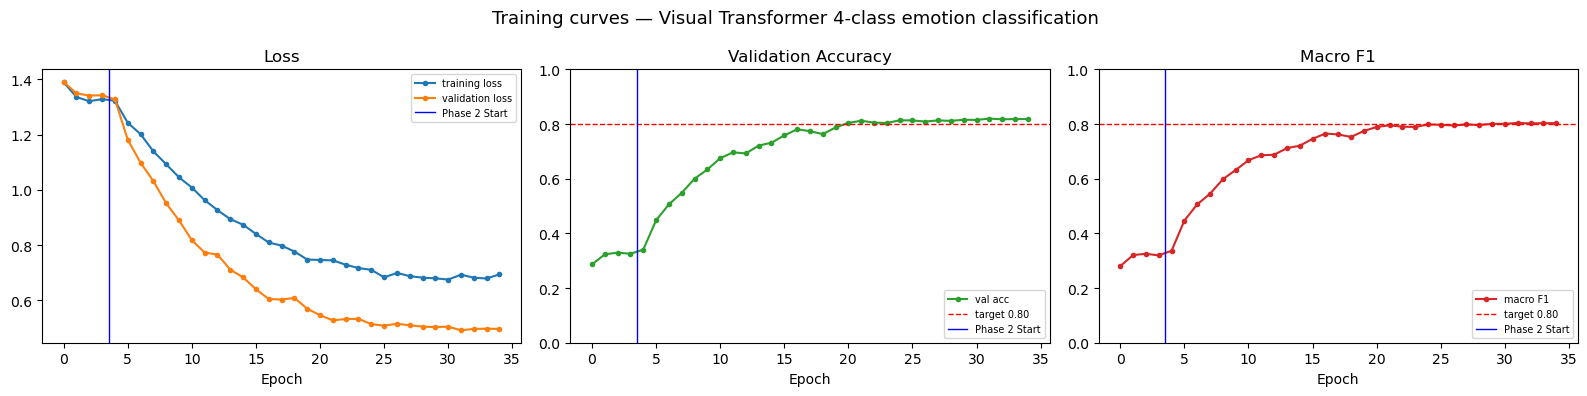

In [39]:
import matplotlib.pyplot as plt
import pandas as pd

df_h = pd.DataFrame(history)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

#def shade_phases(ax):
#    colors = {"P1": "#a9a9a9", "P2a": "#9c9c9c", "P2b(mixup=off)": "#848484",
#              "P2b(mixup=on)": "#656565"}
#    for tag, color in colors.items():
#        mask = df_h["tag"].str.startswith(tag.split("(")[0]) if "P2b" in tag \
#               else df_h["tag"] == tag
#        if mask.any():
#            ax.axvspan(df_h.loc[mask, "epoch"].min() - 0.4,
#                       df_h.loc[mask, "epoch"].max() + 0.4,
#                       alpha=0.3, color=color, label=tag)

ax = axes[0]
ax.plot(df_h["epoch"], df_h["train_loss"], label = "training loss", marker = "o", ms = 3)
ax.plot(df_h["epoch"], df_h["val_loss"],   label = "validation loss",   marker = "o", ms = 3)
ax.axvline(3.5, color = "blue", ls = "-", lw = 1, label = "Phase 2 Start")
#shade_phases(ax)
ax.set_title("Loss")
ax.set_xlabel("Epoch")
ax.legend(fontsize = 7)
ax.grid(False)

ax = axes[1]
ax.plot(df_h["epoch"], df_h["val_acc"], color = "C2", marker = "o", ms = 3, label = "val acc")
ax.axhline(0.80, color = "red", ls = "--", lw = 1, label = "target 0.80")
ax.axvline(3.5, color = "blue", ls = "-", lw = 1, label = "Phase 2 Start")
#shade_phases(ax)
ax.set_title("Validation Accuracy")
ax.set_xlabel("Epoch")
ax.set_ylim(0, 1)
ax.legend(fontsize = 7, loc = "lower right")
ax.grid(False)

ax = axes[2]
ax.plot(df_h["epoch"], df_h["macro_f1"], color = "C3", marker = "o", ms = 3, label = "macro F1")
ax.axhline(0.8, color = "red", ls = "--", lw = 1, label = "target 0.80")
ax.axvline(3.5, color = "blue", ls = "-", lw = 1, label = "Phase 2 Start")
#shade_phases(ax)
ax.set_title("Macro F1")
ax.set_xlabel("Epoch")
ax.set_ylim(0, 1)
ax.legend(fontsize = 7, loc = "lower right")
ax.grid(False)

fig.suptitle("Training curves — Visual Transformer 4-class emotion classification", fontsize = 13)
plt.tight_layout()
plt.savefig("/home/simon/Documents/Zwischen Wörtern und Pixeln/caer-s_4cluster_training-curves.svg")
plt.show()

#save history
df_h.to_csv("training_caer-s_4cluster_history.csv",
           index = False)


## 8. Final Evaluation on Best Checkpoint

BEST CHECKPOINT — validation results
Val loss  : 0.4919
Val acc   : 0.8198
Macro F1  : 0.8040

              precision    recall  f1-score   support

  Optimistic      0.795     0.810     0.802      2000
 Pessimistic      0.906     0.864     0.884      4000
     Hostile      0.882     0.802     0.840      4000
     Neutral      0.620     0.776     0.689      2000

    accuracy                          0.820     12000
   macro avg      0.800     0.813     0.804     12000
weighted avg      0.832     0.820     0.823     12000



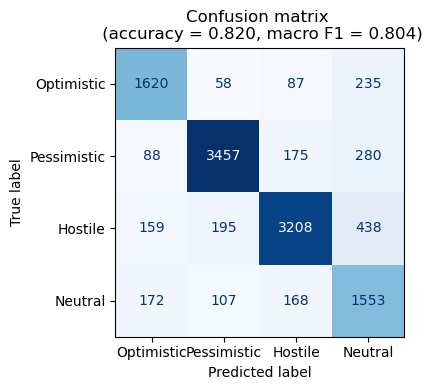

In [45]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.load_state_dict(torch.load("checkpoint_35epochs_good-results.pth", map_location = cfg.device)) #change name of file and map location if necessary
val_loss, val_acc, macro_f1, pcl, report = validate(model, val_loader, criterion, cfg)

print("=" * 55)
print("BEST CHECKPOINT — validation results")
print("=" * 55)
print(f"Val loss  : {val_loss:.4f}")
print(f"Val acc   : {val_acc:.4f}")
print(f"Macro F1  : {macro_f1:.4f}")
print()
print(report)

@torch.no_grad()
def get_all_preds(model, loader, cfg):
    model.eval()
    all_preds, all_labels = [], []
    for images, labels in loader:
        preds = model(images.to(cfg.device)).argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
    return all_labels, all_preds

all_labels, all_preds = get_all_preds(model, val_loader, cfg)
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize = (5, 4))
ConfusionMatrixDisplay(cm, display_labels=EMOTION_NAMES).plot(
    ax=ax, colorbar = False, cmap = "Blues"
)
ax.set_title(f"Confusion matrix \n (accuracy = {val_acc:.3f}, macro F1 = {macro_f1:.3f})")
plt.tight_layout()
plt.savefig("/home/simon/Documents/Zwischen Wörtern und Pixeln/caer-s_4cluster_confusion-matrix.svg")
plt.show()
